# Stage 1: Baseline Models - Experiment Runner

## Purpose
Stage 1 establishes a solid, reproducible baseline for the contract renegotiation problem under weak supervision. It isolates the value of Snorkel-generated probabilistic labels (weak signals), quantifies what gold data adds, and shows how a hybrid approach leverages both sources. This framing directly supports the thesis narrative about weak supervision, two-stage learning, and downstream MAML adaptation (Stage 2) (Ratner et al., 2017; Bach et al., 2019; Rußwurm et al., 2024).

## Scope
**Dataset**: 9,201 contracts across 13 departments, six data views (contractcore, financial, esg, macrologistics, market, news), with gold labels available for a subset of departments and substantial missingness in several views.

**Outputs**: Probabilistic renegotiation pressure scores from Snorkel (renegotiation_prob), plus a hard target_renegotiate label derived from the probability. Stage 2 will reuse Stage 1 representations.


## 1. Imports and project setup

In [1]:
import sys
from pathlib import Path
import re

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("project_root:", project_root)
print("src_path:", src_path)

project_root: /Users/Thomas/Desktop/Master Thesis
src_path: /Users/Thomas/Desktop/Master Thesis/src


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(4) 


from master_thesis.config import FIGURES, MODELS_STAGE1, SEED
from master_thesis.data_utils import (
    load_processed,
    require_columns,
    make_gold_contract_split,
    save_table_versioned,
    save_json_versioned,
)
from master_thesis.baselines import (
    ElasticNetConfig,
    XGBoostConfig,
    BaselineTrainingConfig,
)
from master_thesis.mlp import (
    MLPTrainingConfig,
    set_seed,
)
from master_thesis.stage1 import (
    Stage1ModelConfig,
    fit_stage1_conditions,
    evaluate_stage1_conditions,
    save_stage1_condition_artifacts,
)

## 2. Notebook helpers

These helpers stay in the notebook because they are experiment-specific:

- adding view availability flags
- choosing Stage 1 feature columns
- saving figures with version numbers

In [3]:
def add_view_availability_flags(df_input: pd.DataFrame) -> pd.DataFrame:
    df_output = df_input.copy()

    prefix_map = {
        "financial_data_available": ["fin_"],
        "esg_data_available": ["esg_"],
        "news_data_available": ["news_"],
    }

    market_cols = [
        "avg_vol",
        "std_vol",
        "max_vol",
        "min_vol",
        "vol_stability_score",
        "vol_shock_ratio",
        "vol_trend_slope",
        "avg_market_cap",
        "market_cap_volatility",
        "market_beta_1y",
        "Earnings_per_share_DKK",
        "Book_value_per_share_DKK",
        "avg_shares_outstanding",
        "avg_closing_price",
        "price_volatility_score",
        "price_trend_slope",
        "Price_trends_52_weeks_pct",
        "Price_trends_52 weeks_%",
        "moodys_risk_rating",
    ]

    for new_col, prefixes in prefix_map.items():
        cols = [c for c in df_output.columns if any(c.startswith(prefix) for prefix in prefixes)]
        if cols and new_col not in df_output.columns:
            df_output[new_col] = df_output[cols].notna().any(axis=1).astype(int)

    market_existing = [c for c in market_cols if c in df_output.columns]
    if market_existing and "market_data_available" not in df_output.columns:
        df_output["market_data_available"] = df_output[market_existing].notna().any(axis=1).astype(int)

    return df_output


def get_stage1_feature_columns(
    df_input: pd.DataFrame,
    group_col: str,
    weak_target_col: str,
    gold_col: str,
) -> list[str]:
    leakage_cols = [
        "Unnamed: 0",
        group_col,
        "contract_number",
        "contract_name",
        "supplier_id",
        "supplier_number",
        "supplier_display_name",
        "moodys_bvd_id",
        "Company name Latin alphabet",
        "company_name",
        "gold_department",
        "target_renegotiate",
        weak_target_col,
        gold_col,
        "start_date",
        "expiration_date",
        "execution_at",
        "published_at",
        "contract_name_lower",
        "lf_yes_votes",
        "lf_no_votes",
        "lf_abstain_votes",
        "global_lifecycle_yes_votes",
        "global_lifecycle_no_votes",
        "global_financial_yes_votes",
        "global_financial_no_votes",
        "global_esg_yes_votes",
        "global_esg_no_votes",
        "global_news_yes_votes",
        "global_news_no_votes",
        "global_market_yes_votes",
        "global_market_no_votes",
        "global_supplier_macro_yes_votes",
        "global_supplier_macro_no_votes",
        "logistics_specific_yes_votes",
        "logistics_specific_no_votes",
    ]
    return [c for c in df_input.columns if c not in leakage_cols]


def save_figure_versioned(fig, stem: str, output_dir: Path | None = None, dpi: int = 300) -> Path:
    if output_dir is None:
        output_dir = FIGURES

    output_dir.mkdir(parents=True, exist_ok=True)
    pattern = re.compile(rf"^{re.escape(stem)}_v(\d{{3}})\.png$")
    versions = []

    for path in output_dir.glob(f"{stem}_v*.png"):
        match = pattern.match(path.name)
        if match:
            versions.append(int(match.group(1)))

    next_version = max(versions, default=0) + 1
    output_path = output_dir / f"{stem}_v{next_version:03d}.png"
    fig.savefig(output_path, bbox_inches="tight", dpi=dpi)
    return output_path

## 3. Data loading and split setup

In [4]:
set_seed(SEED)
np.random.seed(SEED)

# EXPERIMENT SETUP 1: Change dataset here
DATA_FILENAME = "contract_with_features_labeled.csv"

# EXPERIMENT SETUP 2: Change weak target column here
WEAK_TARGET_COL = "renegotiation_prob"

# EXPERIMENT SETUP 3: Change gold target column here
GOLD_COL = "gold_y"
GROUP_COL = "contract_id"
DEPARTMENT_COL = "department"

df_stage1 = load_processed(DATA_FILENAME, low_memory=False)
df_stage1 = add_view_availability_flags(df_stage1)

In [5]:
df_stage1.head()

,contract_id,contract_number,contract_name,contract_status,contract_owner_cost_centre,terminated,term_type,start_date,expiration_date,supplier_id,...,global_market_yes_votes,global_market_no_votes,global_supplier_macro_yes_votes,global_supplier_macro_no_votes,logistics_specific_yes_votes,logistics_specific_no_votes,financial_data_available,esg_data_available,news_data_available,market_data_available
0,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,0,0,0,0,0,0,1,1,1,0
1,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,0,0,0,0,0,0,1,1,1,0
2,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,0,0,0,0,0,0,1,1,1,0
3,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,0,0,0,0,0,0,1,1,1,0
4,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,0,0,1,0,0,0,1,1,1,0


In [6]:
require_columns(
    df_stage1,
    [WEAK_TARGET_COL, GOLD_COL, GROUP_COL, DEPARTMENT_COL],
    df_name="df_stage1",
)

print("Shape:", df_stage1.shape)
print("Unique contracts:", df_stage1[GROUP_COL].nunique())
print("Gold-labeled rows:", int(df_stage1[GOLD_COL].notna().sum()))
display(df_stage1.head(3))

Shape: (9201, 227)
Unique contracts: 2209
Gold-labeled rows: 22


,contract_id,contract_number,contract_name,contract_status,contract_owner_cost_centre,terminated,term_type,start_date,expiration_date,supplier_id,...,global_market_yes_votes,global_market_no_votes,global_supplier_macro_yes_votes,global_supplier_macro_no_votes,logistics_specific_yes_votes,logistics_specific_no_votes,financial_data_available,esg_data_available,news_data_available,market_data_available
0,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,0,0,0,0,0,0,1,1,1,0
1,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,0,0,0,0,0,0,1,1,1,0
2,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,0,0,0,0,0,0,1,1,1,0


In [7]:
gold_train_contract_ids, gold_test_contract_ids = make_gold_contract_split(
    df_stage1=df_stage1,
    seed=SEED,
    test_size=0.30,
)

df_gold = df_stage1[df_stage1[GOLD_COL].notna()].copy()
df_gold_train = df_gold[df_gold[GROUP_COL].isin(gold_train_contract_ids)].copy()
df_gold_test = df_gold[df_gold[GROUP_COL].isin(gold_test_contract_ids)].copy()

df_weak_all = df_stage1.copy()
df_weak_train = df_weak_all[~df_weak_all[GROUP_COL].isin(gold_test_contract_ids)].copy()

print("Gold train contracts:", len(gold_train_contract_ids))
print("Gold test contracts :", len(gold_test_contract_ids))
print("Gold train rows     :", len(df_gold_train))
print("Gold test rows      :", len(df_gold_test))

Gold train contracts: 1
Gold test contracts : 1
Gold train rows     : 11
Gold test rows      : 11


## 4. Feature matrix setup

This cell removes identifiers, label-model vote columns, and direct leakage fields.

In [8]:
feature_cols = get_stage1_feature_columns(
    df_input=df_stage1,
    group_col=GROUP_COL,
    weak_target_col=WEAK_TARGET_COL,
    gold_col=GOLD_COL,
)

X_weak_train_df = df_weak_train[feature_cols].copy()
y_weak_train = df_weak_train[WEAK_TARGET_COL].astype(float).values

X_weak_all_df = df_weak_all[feature_cols].copy()
y_weak_all = df_weak_all[WEAK_TARGET_COL].astype(float).values

X_gold_train_df = df_gold_train[feature_cols].copy()
y_gold_train = df_gold_train[GOLD_COL].astype(int).values

X_gold_test_df = df_gold_test[feature_cols].copy()
y_gold_test = df_gold_test[GOLD_COL].astype(int).values

print("Number of Stage 1 features:", len(feature_cols))
print("Weak train shape:", X_weak_train_df.shape)
print("Gold train shape:", X_gold_train_df.shape)
print("Gold test shape :", X_gold_test_df.shape)

Number of Stage 1 features: 195
Weak train shape: (9190, 195)
Gold train shape: (11, 195)
Gold test shape : (11, 195)


## 5. Hyperparameters

This is the main tuning cell for the full Stage 1 run.

In [9]:
baseline_config = BaselineTrainingConfig(
    elastic_net=ElasticNetConfig(
        alpha=0.005,
        l1_ratio=0.5,
        max_iter=1000,         
        random_state=SEED,
    ),
    xgboost=XGBoostConfig(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=SEED,
        n_jobs=4,               
    ),
)


mlp_config = MLPTrainingConfig(
    n_epochs=100,
    patience=10,
    lr=1e-3,
    weight_decay=1e-5,
    train_batch_size=128,
    val_batch_size=256,
    hidden_dim_1=256,
    hidden_dim_2=64,
    dropout=0.3,
)

stage1_config = Stage1ModelConfig(
    baseline_config=baseline_config,
    mlp_config=mlp_config,
)

# EXPERIMENT SETUP 4: Change hybrid training weights here
HYBRID_WEAK_WEIGHT = 1.0
HYBRID_GOLD_WEIGHT = 5.0

experiment_config = {
    "seed": SEED,
    "data_filename": DATA_FILENAME,
    "weak_target_col": WEAK_TARGET_COL,
    "gold_col": GOLD_COL,
    "group_col": GROUP_COL,
    "department_col": DEPARTMENT_COL,
    "hybrid_weak_weight": HYBRID_WEAK_WEIGHT,
    "hybrid_gold_weight": HYBRID_GOLD_WEIGHT,
    "baseline_config": {
        "elastic_net": baseline_config.elastic_net.__dict__,
        "xgboost": baseline_config.xgboost.__dict__,
        "scale_numeric_for_elastic_net": baseline_config.scale_numeric_for_elastic_net,
        "scale_numeric_for_xgboost": baseline_config.scale_numeric_for_xgboost,
        "add_numeric_missing_indicator": baseline_config.add_numeric_missing_indicator,
    },
    "mlp_config": mlp_config.__dict__,
}

## 6. Define Stage 1 conditions

Three experimental conditions (independent training regimes):

**Condition A - Weak-only training**
- **Training data**: Snorkel's probabilistic labels `renegotiation_prob` (soft targets) for all 9,201 contracts.
- **Objective**: Train four baselines using soft targets; evaluate primarily on how well they mimic the weak supervisor (weak-label distillation).
- **Focus**: Layer A diagnostics (RMSE, MAE) and Layer B results on gold data.

**Condition B - Gold-only training**
- **Training data**: Gold labels only (subset where Category managers provided true Yes/No).
- **Objective**: Establish an upper-bound reference for predictive performance.
- **Focus**: Layer B metrics (AUROC, log-loss, Precision@10) on a held-out gold test set.

**Condition C - Hybrid weak + gold training**
- **Training data**: Combine both sources with a principled weighting (giving gold signals higher weight).
- **Objective**: Assess whether adding a small amount of gold information improves performance beyond weak-only training.
- **Rationale**: Tests if gold data meaningfully boosts performance when combined with abundant weak signals, justifying Stage 2 (MAML) (Guo et al., 2025; Jiang et al., 2021).


In [10]:
conditions = {
    "A_weak_only": {
        "X_train_df": X_weak_train_df,
        "y_train": y_weak_train,
        "sample_weight": None,
    },
    "B_gold_only": {
        "X_train_df": X_gold_train_df,
        "y_train": y_gold_train.astype(float),
        "sample_weight": None,
    },
    "C_hybrid": {
        "X_train_df": pd.concat([X_weak_train_df, X_gold_train_df], axis=0).reset_index(drop=True),
        "y_train": np.concatenate([y_weak_train, y_gold_train.astype(float)]),
        "sample_weight": np.concatenate([
            np.full(len(y_weak_train), HYBRID_WEAK_WEIGHT, dtype=float),
            np.full(len(y_gold_train), HYBRID_GOLD_WEIGHT, dtype=float),
        ]),
    },
}

## 7. Train all Stage 1 conditions

Each condition trains:
- Mean Predictor
- Elastic Net
- XGBoost
- MLP

In [11]:
trained_bundles = fit_stage1_conditions(
    conditions=conditions,
    X_val=X_gold_test_df,
    y_val=y_gold_test.astype(float),
    config=stage1_config,
    seed=SEED,
    verbose=True,
)


========== Starting Condition: A_weak_only ==========
[A_weak_only] Fitting Mean Predictor...
[A_weak_only] Mean Predictor fitting complete.
[A_weak_only] Fitting Elastic Net (this can take time if unscaled)...


/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


[A_weak_only] Elastic Net fitting complete.
[A_weak_only] Fitting XGBoost...


/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


[A_weak_only] XGBoost fitting complete.
[A_weak_only] Fitting PyTorch MLP...
Epoch 01 | Train Loss: 2.3526 | Val Loss: 0.6383 | Val RMSE: 0.4718 | Val MAE: 0.4718
Epoch 02 | Train Loss: 0.6915 | Val Loss: 0.6557 | Val RMSE: 0.4809 | Val MAE: 0.4809
Epoch 03 | Train Loss: 0.6905 | Val Loss: 0.6548 | Val RMSE: 0.4805 | Val MAE: 0.4805
Epoch 04 | Train Loss: 0.6916 | Val Loss: 0.6726 | Val RMSE: 0.4896 | Val MAE: 0.4896
Epoch 05 | Train Loss: 0.6905 | Val Loss: 0.6217 | Val RMSE: 0.4630 | Val MAE: 0.4630
Epoch 06 | Train Loss: 0.6908 | Val Loss: 0.6586 | Val RMSE: 0.4824 | Val MAE: 0.4824
Epoch 07 | Train Loss: 0.6906 | Val Loss: 0.6337 | Val RMSE: 0.4694 | Val MAE: 0.4694
Epoch 08 | Train Loss: 0.6902 | Val Loss: 0.6395 | Val RMSE: 0.4724 | Val MAE: 0.4724
Epoch 09 | Train Loss: 0.6904 | Val Loss: 0.6412 | Val RMSE: 0.4733 | Val MAE: 0.4733
Epoch 10 | Train Loss: 0.6903 | Val Loss: 0.6283 | Val RMSE: 0.4665 | Val MAE: 0.4665
Epoch 11 | Train Loss: 0.6905 | Val Loss: 0.6294 | Val RMSE: 0.

/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['contract_value_dkk' 'fin_closing_year' 'fin_Number_of_months'
 'fin_Net_Salesth_DKK' 'fin_Operating_revenue_Turnover_th_DKK'
 'fin_Gross_profit_th_DKK' 'fin_EBIT_th_DKK' 'fin_Net_income_th_DKK'
 'fin_Interest_paid_th_DKK' 'fin_EBITDA_th_DKK'
 'fin_Costs_of_goods_soldth_DKK' 'fin_Total_assets_th_DKK'
 'fin_Non-current_assetsth_DKK' 'fin_Current_assets_th_DKK'
 'fin_Cash_and_cash_equivalent_th_DKK'
 "fin_Total_shareholders'_funds_and_liabilitiesth_DKK"
 'fin_Long_term_debtth_DKK' 'fin_Other_current_assetsth_DKK'
 'fin_Shareholders_funds_th_DKK' 'fin_Current_liabilities_th_DKK'
 'fin_Non_current_liabilities_th_DKK'
 'fin_Other_non_current_liabilitiesth_DKK'
 'fin_Other_current_liabilitiesth_DKK' 'fin_Working_capital_th_DKK'
 'fin_profit_margin' 'fin_Gross_margin' 'fin_EBITDA_margin'
 'fin_ebit_margin' 'fin_current_ratio' 'fin_gea

[C_hybrid] Elastic Net fitting complete.
[C_hybrid] Fitting XGBoost...


/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


[C_hybrid] XGBoost fitting complete.
[C_hybrid] Fitting PyTorch MLP...
Epoch 01 | Train Loss: 2.5242 | Val Loss: 0.6724 | Val RMSE: 0.4895 | Val MAE: 0.4895
Epoch 02 | Train Loss: 0.6922 | Val Loss: 0.6340 | Val RMSE: 0.4695 | Val MAE: 0.4695
Epoch 03 | Train Loss: 0.6912 | Val Loss: 0.6332 | Val RMSE: 0.4691 | Val MAE: 0.4691
Epoch 04 | Train Loss: 0.6908 | Val Loss: 0.6469 | Val RMSE: 0.4763 | Val MAE: 0.4763
Epoch 05 | Train Loss: 0.6905 | Val Loss: 0.6446 | Val RMSE: 0.4751 | Val MAE: 0.4751
Epoch 06 | Train Loss: 0.6905 | Val Loss: 0.6106 | Val RMSE: 0.4570 | Val MAE: 0.4570
Epoch 07 | Train Loss: 0.6901 | Val Loss: 0.6489 | Val RMSE: 0.4774 | Val MAE: 0.4774
Epoch 08 | Train Loss: 0.6900 | Val Loss: 0.6300 | Val RMSE: 0.4674 | Val MAE: 0.4674
Epoch 09 | Train Loss: 0.6897 | Val Loss: 0.6440 | Val RMSE: 0.4748 | Val MAE: 0.4748
Epoch 10 | Train Loss: 0.6891 | Val Loss: 0.6504 | Val RMSE: 0.4781 | Val MAE: 0.4781
Epoch 11 | Train Loss: 0.6891 | Val Loss: 0.5940 | Val RMSE: 0.4479 |

## 8. Evaluate all trained conditions

### Evaluation Framework

**Layer A: Weak-label distillation diagnostics**
- **Metrics**: RMSE, MAE, and R-squared between the model's predictions and Snorkel's `renegotiation_prob`.
- **Interpretation**: "How well does the end model imitate the weak supervisor?" Not a statement about real predictive validity.

**Layer B: Gold-label validity (primary)**
For each condition (A, B, C) and model:
- **AUROC** (discrimination)
- **Log-loss** (probability quality)
- **Precision/Recall/NDCG@10** (top-K ranking for renegotiation pressure)
- **Calibration**: ECE and reliability diagrams
Evaluated on a strictly held-out gold test set to prevent leakage.


In [12]:
evaluation_results = evaluate_stage1_conditions(
    trained_bundles=trained_bundles,
    X_weak_eval=X_weak_all_df,
    y_weak_eval=y_weak_all,
    X_gold_eval=X_gold_test_df,
    y_gold_eval=y_gold_test,
    threshold=0.5,
    k_values=(5, 10, 20),
)

df_layer_a = evaluation_results["df_weak_results_all"].copy()
df_layer_b = evaluation_results["df_gold_results_all"].copy()

display(df_layer_a.sort_values(["rmse", "mae"], ascending=True))
display(df_layer_b.sort_values("gold_auroc", ascending=False))

/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features wi

,model,rmse,mae,r2,pred_mean,true_mean,condition,model_base
2,XGBoost_A_weak_only,0.002721,0.001325,9.999125e-01,0.540461,0.540562,A_weak_only,XGBoost
10,XGBoost_C_hybrid,0.002794,0.001355,9.999078e-01,0.540458,0.540562,C_hybrid,XGBoost
1,Elastic Net_A_weak_only,0.146937,0.111221,7.449310e-01,0.534849,0.540562,A_weak_only,Elastic Net
9,Elastic Net_C_hybrid,0.147110,0.111368,7.443283e-01,0.535105,0.540562,C_hybrid,Elastic Net
11,MLP_C_hybrid,0.263057,0.221702,1.824795e-01,0.558537,0.540562,C_hybrid,MLP
8,Mean Predictor_C_hybrid,0.290938,0.233240,0.000000e+00,0.540562,0.540562,C_hybrid,Mean Predictor
3,MLP_A_weak_only,0.290938,0.233185,-1.521496e-07,0.540449,0.540562,A_weak_only,MLP
0,Mean Predictor_A_weak_only,0.290939,0.232973,-3.572773e-06,0.540013,0.540562,A_weak_only,Mean Predictor
4,Mean Predictor_B_gold_only,0.543809,0.459438,-2.493740e+00,1.000000,0.540562,B_gold_only,Mean Predictor
5,Elastic Net_B_gold_only,0.543809,0.459438,-2.493740e+00,1.000000,0.540562,B_gold_only,Elastic Net


,model,gold_auroc,gold_ap,gold_logloss,gold_brier,gold_ece,gold_f1,gold_accuracy,gold_pred_mean,gold_true_mean,...,recall_at_5,ndcg_at_5,precision_at_10,recall_at_10,ndcg_at_10,precision_at_20,recall_at_20,ndcg_at_20,condition,model_base
0,Mean Predictor_A_weak_only,NaN,NaN,6.161629e-01,2.115885e-01,4.599875e-01,1.0,1.0,0.540013,1.0,...,0.454545,1.0,1.0,0.909091,1.0,1.0,1.0,1.0,A_weak_only,Mean Predictor
1,Elastic Net_A_weak_only,NaN,NaN,4.798596e-02,6.986208e-03,4.401497e-02,1.0,1.0,0.955985,1.0,...,0.454545,1.0,1.0,0.909091,1.0,1.0,1.0,1.0,A_weak_only,Elastic Net
2,XGBoost_A_weak_only,NaN,NaN,3.494412e-04,4.815054e-07,3.492002e-04,1.0,1.0,0.999651,1.0,...,0.454545,1.0,1.0,0.909091,1.0,1.0,1.0,1.0,A_weak_only,XGBoost
3,MLP_A_weak_only,NaN,NaN,6.153551e-01,2.111872e-01,4.595510e-01,1.0,1.0,0.540449,1.0,...,0.454545,1.0,1.0,0.909091,1.0,1.0,1.0,1.0,A_weak_only,MLP
4,Mean Predictor_B_gold_only,NaN,NaN,1.000000e-08,1.000000e-16,1.000000e-08,1.0,1.0,1.000000,1.0,...,0.454545,1.0,1.0,0.909091,1.0,1.0,1.0,1.0,B_gold_only,Mean Predictor
5,Elastic Net_B_gold_only,NaN,NaN,1.000000e-08,1.000000e-16,1.000000e-08,1.0,1.0,1.000000,1.0,...,0.454545,1.0,1.0,0.909091,1.0,1.0,1.0,1.0,B_gold_only,Elastic Net
6,XGBoost_B_gold_only,NaN,NaN,1.000000e-08,1.000000e-16,1.000000e-08,1.0,1.0,1.000000,1.0,...,0.454545,1.0,1.0,0.909091,1.0,1.0,1.0,1.0,B_gold_only,XGBoost
7,MLP_B_gold_only,NaN,NaN,1.000000e-08,1.000000e-16,1.000000e-08,1.0,1.0,1.000000,1.0,...,0.454545,1.0,1.0,0.909091,1.0,1.0,1.0,1.0,B_gold_only,MLP
8,Mean Predictor_C_hybrid,NaN,NaN,6.151451e-01,2.110829e-01,4.594376e-01,1.0,1.0,0.540562,1.0,...,0.454545,1.0,1.0,0.909091,1.0,1.0,1.0,1.0,C_hybrid,Mean Predictor
9,Elastic Net_C_hybrid,NaN,NaN,4.503762e-02,6.293563e-03,4.148111e-02,1.0,1.0,0.958519,1.0,...,0.454545,1.0,1.0,0.909091,1.0,1.0,1.0,1.0,C_hybrid,Elastic Net


## 9. Save versioned tables and Stage 1 pretrained artifacts

In [13]:
path_config = save_json_versioned(experiment_config, "stage1_experiment_config")
path_layer_a = save_table_versioned(df_layer_a, "stage1_layer_a_weak_distillation")
path_layer_b = save_table_versioned(df_layer_b, "stage1_layer_b_gold_evaluation")

saved_condition_paths = {}

for condition_name, trained_bundle in trained_bundles.items():
    condition_dir = MODELS_STAGE1 / condition_name

    saved_condition_paths[condition_name] = save_stage1_condition_artifacts(
        trained_bundle=trained_bundle,
        output_dir=condition_dir,
        save_xgb_importance=True,
    )

    history_path = save_table_versioned(
        trained_bundle["mlp_bundle"]["history"],
        f"stage1_mlp_history_{condition_name}",
    )
    saved_condition_paths[condition_name]["history_versioned_path"] = history_path

print("Saved config:", path_config)
print("Saved layer A table:", path_layer_a)
print("Saved layer B table:", path_layer_b)
saved_condition_paths

Saved config: /Users/Thomas/Desktop/Master Thesis/reports/tables/stage1_experiment_config_v001.json
Saved layer A table: /Users/Thomas/Desktop/Master Thesis/reports/tables/stage1_layer_a_weak_distillation_v001.csv
Saved layer B table: /Users/Thomas/Desktop/Master Thesis/reports/tables/stage1_layer_b_gold_evaluation_v001.csv


{'A_weak_only': {'weights_path': PosixPath('/Users/Thomas/Desktop/Master Thesis/models/stage_1/A_weak_only/mlp_pretrained.pt'),
  'preprocessor_path': PosixPath('/Users/Thomas/Desktop/Master Thesis/models/stage_1/A_weak_only/mlp_pretrained_preprocessor.joblib'),
  'history_path': PosixPath('/Users/Thomas/Desktop/Master Thesis/models/stage_1/A_weak_only/mlp_pretrained_history.csv'),
  'tabular_results_path': PosixPath('/Users/Thomas/Desktop/Master Thesis/models/stage_1/A_weak_only/tabular_results.csv'),
  'xgboost_feature_importance_path': PosixPath('/Users/Thomas/Desktop/Master Thesis/models/stage_1/A_weak_only/xgboost_feature_importance.csv'),
  'history_versioned_path': PosixPath('/Users/Thomas/Desktop/Master Thesis/reports/tables/stage1_mlp_history_A_weak_only_v001.csv')},
 'B_gold_only': {'weights_path': PosixPath('/Users/Thomas/Desktop/Master Thesis/models/stage_1/B_gold_only/mlp_pretrained.pt'),
  'preprocessor_path': PosixPath('/Users/Thomas/Desktop/Master Thesis/models/stage_1/

## 10. Plots

The notebook saves:
- weak-label RMSE comparison
- gold-label AUROC comparison
- gold-label log-loss comparison
- one MLP training-history plot per condition

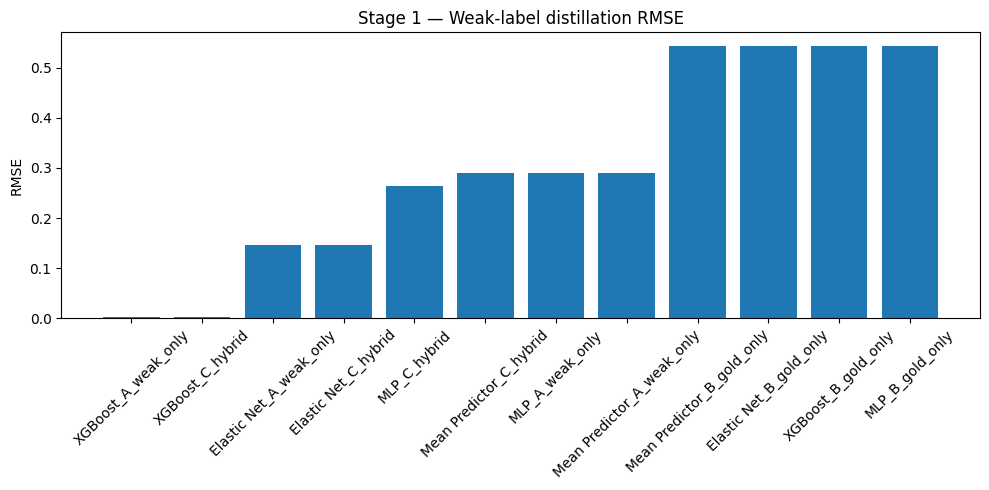

Saved figure: /Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_layer_a_rmse_v001.png


In [14]:
# --- Plot 1: Layer A weak-label RMSE
df_plot_a = df_layer_a.sort_values("rmse", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_plot_a["model"], df_plot_a["rmse"])
ax.set_title("Stage 1 — Weak-label distillation RMSE")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

path_fig_a = save_figure_versioned(fig, "stage1_layer_a_rmse")
plt.show()

print("Saved figure:", path_fig_a)

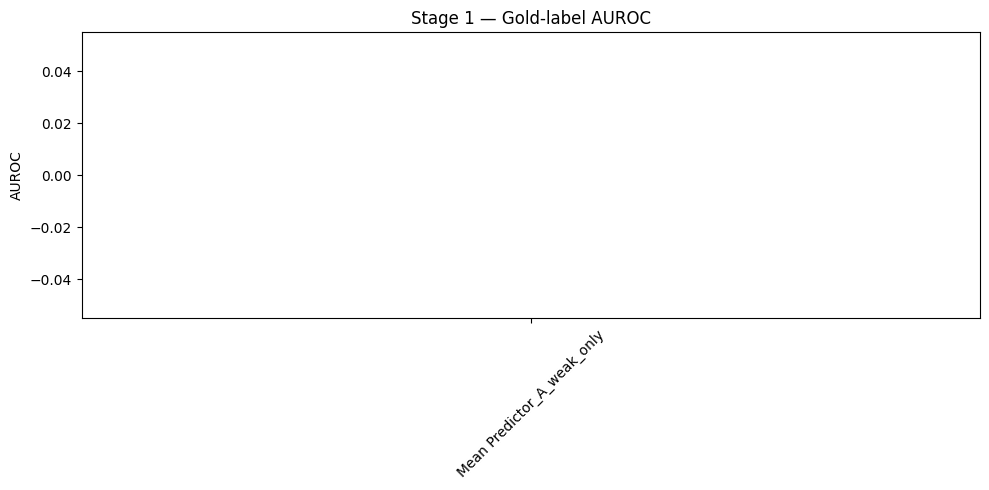

Saved figure: /Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_gold_auroc_v001.png


In [15]:
# --- Plot 2: Layer B gold-label AUROC
df_plot_b_auc = df_layer_b.sort_values("gold_auroc", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_plot_b_auc["model"], df_plot_b_auc["gold_auroc"])
ax.set_title("Stage 1 — Gold-label AUROC")
ax.set_ylabel("AUROC")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

path_fig_b_auc = save_figure_versioned(fig, "stage1_gold_auroc")
plt.show()

print("Saved figure:", path_fig_b_auc)

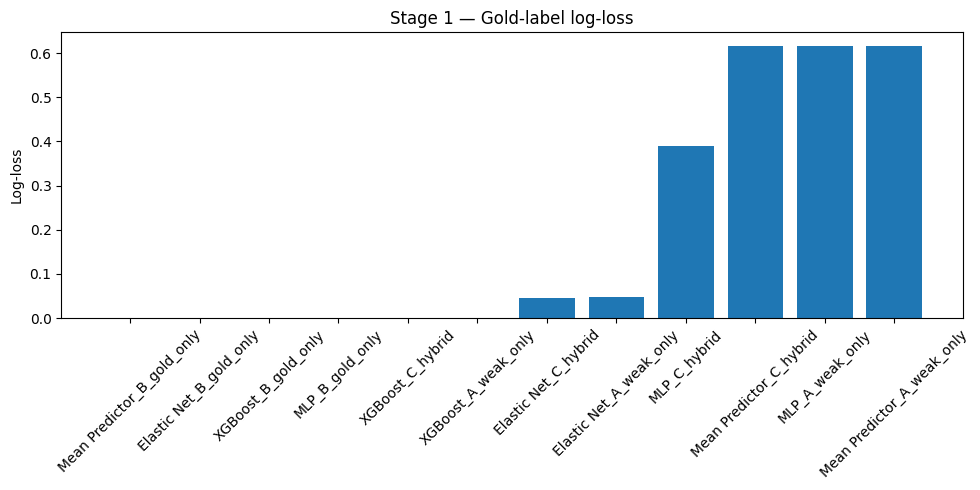

Saved figure: /Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_gold_logloss_v001.png


In [16]:
# --- Plot 3: Layer B gold-label log-loss
df_plot_b_logloss = df_layer_b.sort_values("gold_logloss", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_plot_b_logloss["model"], df_plot_b_logloss["gold_logloss"])
ax.set_title("Stage 1 — Gold-label log-loss")
ax.set_ylabel("Log-loss")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

path_fig_b_logloss = save_figure_versioned(fig, "stage1_gold_logloss")
plt.show()

print("Saved figure:", path_fig_b_logloss)

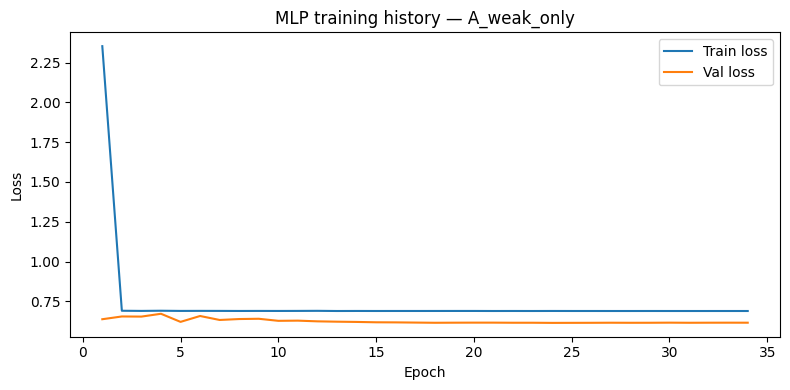

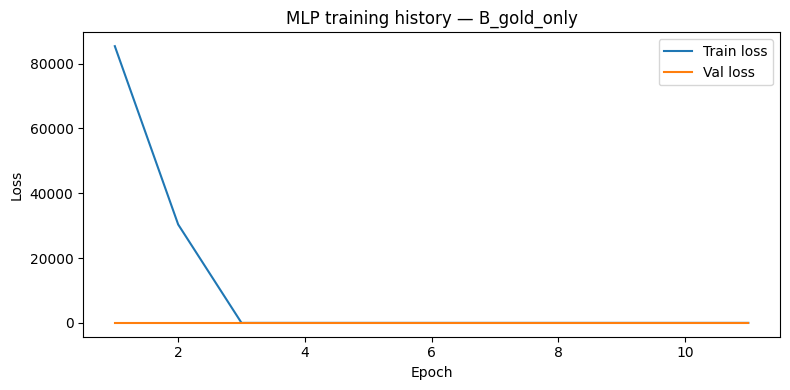

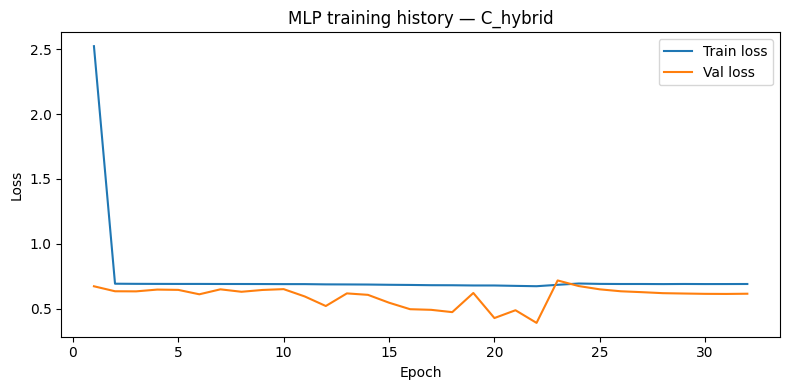

{'A_weak_only': PosixPath('/Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_mlp_history_A_weak_only_v001.png'),
 'B_gold_only': PosixPath('/Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_mlp_history_B_gold_only_v001.png'),
 'C_hybrid': PosixPath('/Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_mlp_history_C_hybrid_v001.png')}

In [17]:
# --- Plot 4: MLP training history per condition
mlp_history_paths = {}

for condition_name, trained_bundle in trained_bundles.items():
    df_history = trained_bundle["mlp_bundle"]["history"].copy()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(df_history["epoch"], df_history["train_loss"], label="Train loss")
    ax.plot(df_history["epoch"], df_history["val_loss"], label="Val loss")
    ax.set_title(f"MLP training history — {condition_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()

    fig_path = save_figure_versioned(fig, f"stage1_mlp_history_{condition_name}")
    mlp_history_paths[condition_name] = fig_path
    plt.show()

mlp_history_paths

## 11. Final summary views

In [18]:
df_gold_summary = df_layer_b[
    [
        "model",
        "condition",
        "model_base",
        "gold_auroc",
        "gold_ap",
        "gold_logloss",
        "gold_brier",
        "gold_ece",
        "gold_f1",
        "gold_accuracy",
        "precision_at_5",
        "precision_at_10",
        "precision_at_20",
        "recall_at_5",
        "recall_at_10",
        "recall_at_20",
        "ndcg_at_5",
        "ndcg_at_10",
        "ndcg_at_20",
    ]
].copy()

display(df_gold_summary.sort_values(["gold_auroc", "gold_ap"], ascending=False))

,model,condition,model_base,gold_auroc,gold_ap,gold_logloss,gold_brier,gold_ece,gold_f1,gold_accuracy,precision_at_5,precision_at_10,precision_at_20,recall_at_5,recall_at_10,recall_at_20,ndcg_at_5,ndcg_at_10,ndcg_at_20
0,Mean Predictor_A_weak_only,A_weak_only,Mean Predictor,NaN,NaN,6.161629e-01,2.115885e-01,4.599875e-01,1.0,1.0,1.0,1.0,1.0,0.454545,0.909091,1.0,1.0,1.0,1.0
1,Elastic Net_A_weak_only,A_weak_only,Elastic Net,NaN,NaN,4.798596e-02,6.986208e-03,4.401497e-02,1.0,1.0,1.0,1.0,1.0,0.454545,0.909091,1.0,1.0,1.0,1.0
2,XGBoost_A_weak_only,A_weak_only,XGBoost,NaN,NaN,3.494412e-04,4.815054e-07,3.492002e-04,1.0,1.0,1.0,1.0,1.0,0.454545,0.909091,1.0,1.0,1.0,1.0
3,MLP_A_weak_only,A_weak_only,MLP,NaN,NaN,6.153551e-01,2.111872e-01,4.595510e-01,1.0,1.0,1.0,1.0,1.0,0.454545,0.909091,1.0,1.0,1.0,1.0
4,Mean Predictor_B_gold_only,B_gold_only,Mean Predictor,NaN,NaN,1.000000e-08,1.000000e-16,1.000000e-08,1.0,1.0,1.0,1.0,1.0,0.454545,0.909091,1.0,1.0,1.0,1.0
5,Elastic Net_B_gold_only,B_gold_only,Elastic Net,NaN,NaN,1.000000e-08,1.000000e-16,1.000000e-08,1.0,1.0,1.0,1.0,1.0,0.454545,0.909091,1.0,1.0,1.0,1.0
6,XGBoost_B_gold_only,B_gold_only,XGBoost,NaN,NaN,1.000000e-08,1.000000e-16,1.000000e-08,1.0,1.0,1.0,1.0,1.0,0.454545,0.909091,1.0,1.0,1.0,1.0
7,MLP_B_gold_only,B_gold_only,MLP,NaN,NaN,1.000000e-08,1.000000e-16,1.000000e-08,1.0,1.0,1.0,1.0,1.0,0.454545,0.909091,1.0,1.0,1.0,1.0
8,Mean Predictor_C_hybrid,C_hybrid,Mean Predictor,NaN,NaN,6.151451e-01,2.110829e-01,4.594376e-01,1.0,1.0,1.0,1.0,1.0,0.454545,0.909091,1.0,1.0,1.0,1.0
9,Elastic Net_C_hybrid,C_hybrid,Elastic Net,NaN,NaN,4.503762e-02,6.293563e-03,4.148111e-02,1.0,1.0,1.0,1.0,1.0,0.454545,0.909091,1.0,1.0,1.0,1.0
